# Simulação Computacional

## Metodologia

A simulação computacional foi desenvolvida em Python com o objetivo de verificar, de forma numérica e gráfica, o comportamento dos cinco sistemas discretos apresentados anteriormente.

Para isso, foi utilizada uma sequência de entrada composta por um pulso discreto finito. A partir dessa entrada, cada sistema foi aplicado individualmente, permitindo observar as diferenças provocadas pelas operações de escala, atraso, não linearidade, avanço temporal e variação do ganho.

A metodologia adotada pode ser dividida nas seguintes etapas:

1. Definição do vetor de tempo discreto $n$.
2. Geração da sequência de entrada $x[n]$.
3. Aplicação da sequência aos cinco sistemas.
4. Armazenamento dos resultados em um DataFrame utilizando a biblioteca Pandas.
5. Exibição dos valores numéricos obtidos.
6. Representação gráfica das sequências utilizando gráficos de haste (`stem`).
7. Comparação visual entre a entrada e as respostas dos diferentes sistemas.

A sequência de entrada utilizada é definida como um pulso unitário finito:

$$
x[n] =
\begin{cases}
1, & 0 \leq n \leq 5 \\
0, & \text{caso contrário}
\end{cases}
$$

O vetor de índices discretos utilizado na simulação é:

$$
n \in [-2,7]
$$

Dessa forma, é possível observar não apenas a região em que o pulso está ativo, mas também o comportamento dos sistemas antes e depois do pulso.

## Implementação Computacional

O código foi desenvolvido utilizando as bibliotecas NumPy, Pandas, Matplotlib e Seaborn.

* NumPy: geração dos vetores e realização das operações numéricas;
* Pandas: organização dos resultados em formato tabular;
* Matplotlib: construção dos gráficos;
* Seaborn: configuração do estilo visual das figuras.

**Código da simulação:**

In [3]:
# ============================================================
# IMPORTAÇÕES E CONFIGURAÇÕES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do tema gráfico
sns.set_theme(
    style="whitegrid",
    context="paper",
    font="Inter"
)

plt.rcParams["font.family"] = "sans-serif"

 n  Entrada x[n]  A: 2x[n]  B: x[n] + x[n-1]  C: x²[n]  D: x[n+1]  E: n*x[n]
-2           0.0       0.0               0.0       0.0        0.0       -0.0
-1           0.0       0.0               0.0       0.0        1.0       -0.0
 0           1.0       2.0               1.0       1.0        1.0        0.0
 1           1.0       2.0               2.0       1.0        1.0        1.0
 2           1.0       2.0               2.0       1.0        1.0        2.0
 3           1.0       2.0               2.0       1.0        1.0        3.0
 4           1.0       2.0               2.0       1.0        1.0        4.0
 5           1.0       2.0               2.0       1.0        0.0        5.0
 6           0.0       0.0               1.0       0.0        0.0        0.0
 7           0.0       0.0               0.0       0.0        0.0        0.0


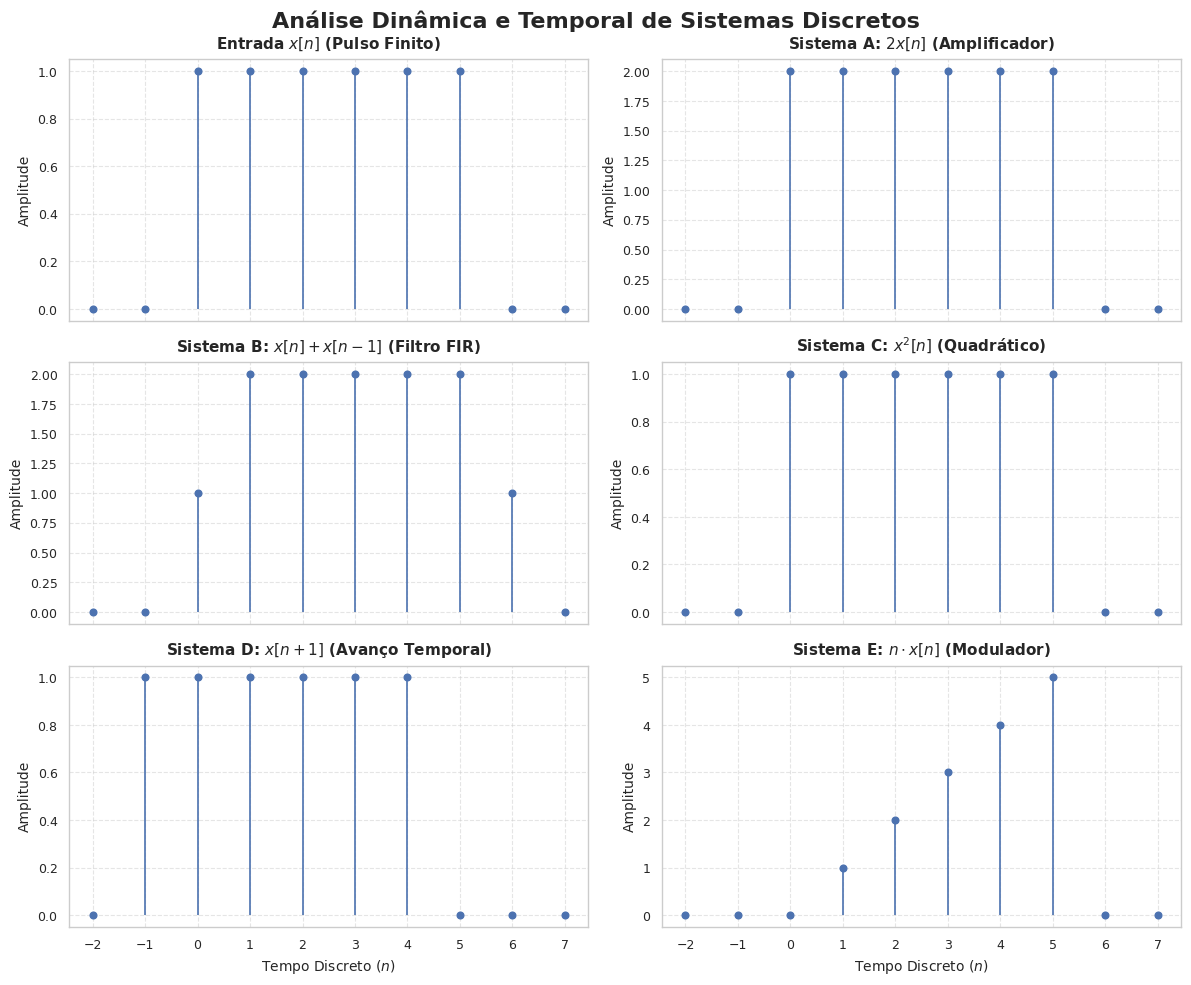

In [6]:
# ============================================================
# FUNÇÃO DE GERAÇÃO DO SINAL DE ENTRADA
# ============================================================

def signal_x(n_vec):
    """
    Gera o sinal de entrada:
    pulso unitário para 0 <= n <= 5.
    """
    return np.where(
        (n_vec >= 0) & (n_vec <= 5),
        1.0,
        0.0
    )


# ============================================================
# 1. DEFINIÇÃO DO VETOR DE TEMPO DISCRETO
# ============================================================

n = np.arange(-2, 8)

# Geração da sequência de entrada
x = signal_x(n)


# ============================================================
# 2. PROCESSAMENTO NOS CINCO SISTEMAS
# ============================================================

# Sistema A: y[n] = 2x[n]
y_A = 2 * x

# Sistema B: y[n] = x[n] + x[n-1]
y_B = x + signal_x(n - 1)

# Sistema C: y[n] = x²[n]
y_C = x ** 2

# Sistema D: y[n] = x[n+1]
y_D = signal_x(n + 1)

# Sistema E: y[n] = n · x[n]
y_E = n * x


# ============================================================
# 3. CONSTRUÇÃO DO DATAFRAME
# ============================================================

df_resultados = pd.DataFrame({
    "n": n,
    "Entrada x[n]": x,
    "A: 2x[n]": y_A,
    "B: x[n] + x[n-1]": y_B,
    "C: x²[n]": y_C,
    "D: x[n+1]": y_D,
    "E: n*x[n]": y_E
})


# ============================================================
# 4. EXIBIÇÃO DOS RESULTADOS NUMÉRICOS
# ============================================================

print(df_resultados.to_string(index=False))


# ============================================================
# 5. CONFIGURAÇÃO DA FIGURA
# ============================================================

fig, axs = plt.subplots(
    3,
    2,
    figsize=(12, 10),
    sharex=True
)

fig.suptitle(
    "Análise Dinâmica e Temporal de Sistemas Discretos",
    fontsize=16,
    fontweight="bold",
    y=0.98
)


# ============================================================
# 6. DEFINIÇÃO DOS SINAIS E TÍTULOS DOS GRÁFICOS
# ============================================================

sistemas = [
    (
        x,
        r"Entrada $x[n]$ (Pulso Finito)",
        axs[0, 0]
    ),
    (
        y_A,
        r"Sistema A: $2x[n]$ (Amplificador)",
        axs[0, 1]
    ),
    (
        y_B,
        r"Sistema B: $x[n]+x[n-1]$ (Filtro FIR)",
        axs[1, 0]
    ),
    (
        y_C,
        r"Sistema C: $x^2[n]$ (Quadrático)",
        axs[1, 1]
    ),
    (
        y_D,
        r"Sistema D: $x[n+1]$ (Avanço Temporal)",
        axs[2, 0]
    ),
    (
        y_E,
        r"Sistema E: $n \cdot x[n]$ (Modulador)",
        axs[2, 1]
    )
]


# ============================================================
# 7. CONSTRUÇÃO DOS GRÁFICOS DE HASTE
# ============================================================

for sinal, titulo, ax in sistemas:

    markerline, stemlines, baseline = ax.stem(
        n,
        sinal,
        basefmt=" "
    )

    ax.set_title(
        titulo,
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    ax.set_ylabel(
        "Amplitude",
        fontsize=10
    )

    ax.set_xticks(n)

    ax.tick_params(
        labelsize=9
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5
    )


# ============================================================
# 8. CONFIGURAÇÃO DOS EIXOS INFERIORES
# ============================================================

axs[2, 0].set_xlabel(
    "Tempo Discreto ($n$)",
    fontsize=10
)

axs[2, 1].set_xlabel(
    "Tempo Discreto ($n$)",
    fontsize=10
)


# ============================================================
# 9. AJUSTES FINAIS DA FIGURA
# ============================================================

plt.tight_layout()

plt.subplots_adjust(
    top=0.93
)

plt.show()

## Funcionamento da Simulação

Inicialmente, o vetor de índices discretos é definido por:

$$
n = \{-2,-1,0,1,2,3,4,5,6,7\}
$$

Em seguida, a função `signal_x()` gera o pulso de entrada. Para os índices entre $0$ e $5$, o valor da sequência é igual a $1$. Nos demais índices, o valor é igual a zero.

A sequência resultante é, portanto:

$$
x[n] =
[0,0,1,1,1,1,1,1,0,0]
$$

Essa entrada é aplicada individualmente aos cinco sistemas.

### Sistema A

O primeiro sistema realiza uma multiplicação por dois:

$$
y_A[n] = 2x[n]
$$

Consequentemente, todos os valores não nulos da entrada passam de $1$ para $2$.

### Sistema B

O segundo sistema soma a amostra atual com a amostra anterior:

$$
y_B[n] = x[n] + x[n-1]
$$

Essa operação introduz uma dependência temporal, fazendo com que o sistema apresente memória.

### Sistema C

O terceiro sistema eleva cada amostra ao quadrado:

$$
y_C[n] = x^2[n]
$$

Como os valores utilizados na entrada são apenas $0$ e $1$, o resultado permanece igual à entrada. Apesar disso, o sistema continua sendo não linear, pois a operação de elevação ao quadrado não satisfaz a propriedade de homogeneidade.

### Sistema D

O quarto sistema realiza um avanço temporal:

$$
y_D[n] = x[n+1]
$$

Nesse caso, cada valor da saída corresponde à amostra seguinte da entrada. Como consequência, o pulso aparece deslocado para a esquerda no eixo temporal.

### Sistema E

O quinto sistema multiplica a entrada pelo índice temporal:

$$
y_E[n] = n \cdot x[n]
$$

Nesse caso, o valor da saída depende tanto da amplitude da entrada quanto da posição temporal da amostra.

## Organização dos Resultados

Os resultados dos cinco sistemas são armazenados em um DataFrame da biblioteca Pandas. Essa estrutura permite organizar os valores de forma tabular, facilitando a comparação entre a entrada e as diferentes saídas.

A tabela possui as seguintes colunas:

| Coluna        | Significado              |
| :------------ | :----------------------- |
| $n$           | Índice temporal discreto |
| $x[n]$        | Sequência de entrada     |
| $2x[n]$       | Saída do Sistema A       |
| $x[n]+x[n-1]$ | Saída do Sistema B       |
| $x^2[n]$      | Saída do Sistema C       |
| $x[n+1]$      | Saída do Sistema D       |
| $n\cdot x[n]$ | Saída do Sistema E       |

Essa organização permite comparar diretamente os valores correspondentes a cada instante discreto.

## Visualização dos Resultados

Para representar sinais discretos, foram utilizados gráficos de haste (`stem`). Essa representação é adequada para sinais discretos porque evidencia individualmente cada amostra e sua posição no eixo temporal.

A figura final é organizada em seis gráficos:

* entrada $x[n]$;
* saída do Sistema A;
* saída do Sistema B;
* saída do Sistema C;
* saída do Sistema D;
* saída do Sistema E.

A utilização de uma disposição em três linhas e duas colunas permite visualizar simultaneamente todos os sinais e facilita a comparação entre as respostas.

## Resultados da Simulação

A simulação confirma numericamente os comportamentos previstos na análise matemática.

Para o Sistema A, observa-se apenas uma alteração na amplitude:

$$
y_A[n] = 2x[n]
$$

Para o Sistema B, observa-se a presença de uma contribuição adicional proveniente da amostra anterior, característica de um sistema com memória:

$$
y_B[n] = x[n] + x[n-1]
$$

No Sistema C, os valores da sequência permanecem iguais devido à natureza binária da entrada:

$$
0^2 = 0
$$

e

$$
1^2 = 1
$$

Entretanto, a análise matemática continua indicando que o sistema é não linear.

No Sistema D, observa-se o deslocamento temporal da sequência para a esquerda, evidenciando o comportamento não causal:

$$
y_D[n] = x[n+1]
$$

Por fim, o Sistema E apresenta amplitudes proporcionais ao índice temporal:

$$
y_E[n] = n \cdot x[n]
$$

resultando em valores crescentes enquanto o pulso permanece ativo.

## Discussão da Simulação

A implementação computacional permite confirmar, por meio de dados numéricos e gráficos, as propriedades determinadas analiticamente.

A comparação dos sinais mostra que operações aparentemente simples podem produzir comportamentos significativamente diferentes. A multiplicação por uma constante altera apenas a amplitude, enquanto operações envolvendo índices deslocados alteram a posição temporal das amostras.

O Sistema B demonstra diretamente o efeito da memória, pois a saída em determinado instante depende também de uma amostra anterior. O Sistema D evidencia a diferença entre um deslocamento para o passado e um deslocamento para o futuro, sendo necessário acessar uma amostra futura para determinar a saída.

O Sistema C demonstra que a aparência dos resultados numéricos depende da sequência de entrada. Embora a saída seja visualmente igual à entrada para o pulso utilizado, o sistema é matematicamente não linear.

Por sua vez, o Sistema E evidencia que linearidade não implica estabilidade BIBO nem invariância no tempo. O fator $n$ faz com que o ganho do sistema varie ao longo do tempo e possa crescer indefinidamente.

Assim, a simulação computacional complementa a análise matemática e permite verificar experimentalmente as propriedades de memória, causalidade, linearidade, invariância no tempo e estabilidade BIBO.